In [1]:
from pathlib import Path
import os
import random

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "creditcard_2023.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "creditcard_2023.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(RESULTS_DIR / ".matplotlib"))
os.environ.setdefault("KERAS_HOME", str(RESULTS_DIR / ".keras"))
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
df = pd.read_csv(DATA_PATH)

In [3]:
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


Features do nosso dataset possui seguintes descrições:
id: Identificador único de cada transação
V1-V28: Features anonimizadas representando vários atributos de transação (e.g., hora, local, etc.)
Amount: Quantia da transação
Class: Label binário indicando se a transação é fraudulenta (1) ou não (0)

### Primeiramente, limpar os dados retirando informações com "NA" e ajustando variáveis de treinamento e teste

In [4]:
df_new = df.dropna()

In [5]:
df_new = df_new.drop(columns=['id'])

In [6]:
df_new.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,0.637735,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,0.529808,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,0.690708,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,0.575231,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,0.968046,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


### Agora separar as features do target

In [7]:
X = df_new.drop(columns=['Class'])
y = df_new['Class']




### separando treino, validação e teste:




In [8]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

### Posteriormente, normalizamos os valores de Amount

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Aqui uma diferença bem interessante de Autoencoders para Regressão Logística vem do fato de filtrar o treino usando somente as transações **normais**.

In [10]:
X_train_normal = X_train_scaled[y_train == 0]
X_val_normal = X_val_scaled[y_val == 0]

In [11]:
input_dim = X_train_normal.shape[1]

autoencoder = keras.Sequential([
    keras.Input(shape=(input_dim,)),

    # Encoder
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),

    # Decoder
    layers.Dense(16, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 29)             │           957 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,269 (12.77 KB)

 Trainable params: 3,269 (12.77 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=50,
    batch_size=256,
    validation_data=(X_val_normal, X_val_normal),
    shuffle=True
)

Epoch 1/50


  1/778 ━━━━━━━━━━━━━━━━━━━━ 35:43 3s/step - loss: 0.7785

 13/778 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7296  

 26/778 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7128

 42/778 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6937

...

722/778 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1562

737/778 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1562

752/778 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1562

765/778 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1562

778/778 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1565 - val_loss: 0.1622


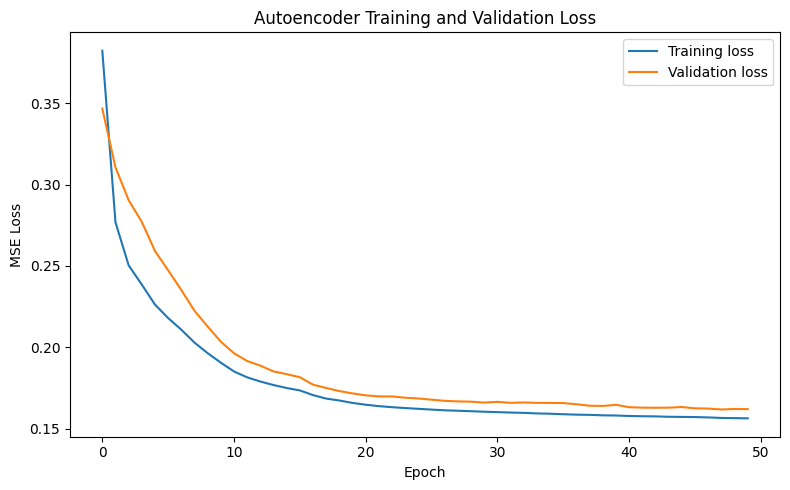

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "autoencoder_training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

### Próxima etapa é fazer o cálculo de errp de reconstrução

In [14]:
import numpy as np

X_val_pred = autoencoder.predict(X_val_scaled)

reconstruction_error_val = np.mean(
    np.square(X_val_scaled - X_val_pred),
    axis=1
)

   1/2666 ━━━━━━━━━━━━━━━━━━━━ 8:41 196ms/step

  21/2666 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step    

  45/2666 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step

  68/2666 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step

  92/2666 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step

...

2607/2666 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2634/2666 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2659/2666 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2666/2666 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2666/2666 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


### Definição de threshold. Aqui, utilizaremos 99%

In [15]:
reconstruction_error_val_normal = reconstruction_error_val[y_val == 0]

threshold = np.percentile(reconstruction_error_val_normal, 99)

print("Threshold:", threshold)

Threshold: 0.8154891932592041


In [16]:
X_test_pred = autoencoder.predict(X_test_scaled)

reconstruction_error_test = np.mean(
    np.square(X_test_scaled - X_test_pred),
    axis=1
)

y_test_pred = (reconstruction_error_test > threshold).astype(int)

   1/2666 ━━━━━━━━━━━━━━━━━━━━ 2:35 58ms/step

  26/2666 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step   

  47/2666 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step

  67/2666 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step

  92/2666 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step

...

2576/2666 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2602/2666 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2628/2666 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2655/2666 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

2666/2666 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


[[42229   419]
 [21548 21099]]
              precision    recall  f1-score   support

           0       0.66      0.99      0.79     42648
           1       0.98      0.49      0.66     42647

    accuracy                           0.74     85295
   macro avg       0.82      0.74      0.73     85295
weighted avg       0.82      0.74      0.73     85295



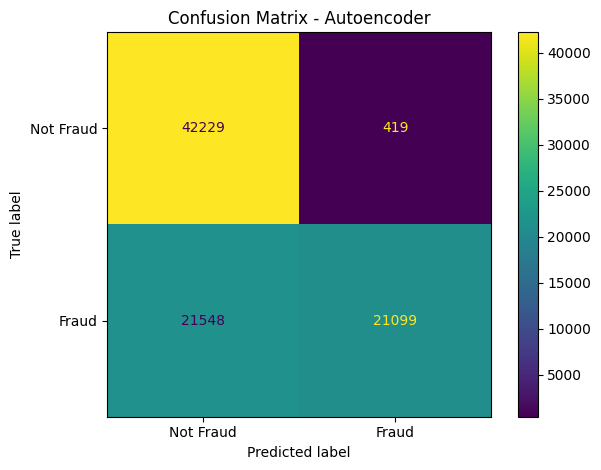

In [17]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)

cm = confusion_matrix(y_test, y_test_pred)
report = classification_report(y_test, y_test_pred)

print(cm)
print(report)

with open(RESULTS_DIR / "autoencoder_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Fraud", "Fraud"]
)
disp.plot()
plt.title("Confusion Matrix - Autoencoder")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix_autoencoder.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, reconstruction_error_test)
pr_auc = average_precision_score(y_test, reconstruction_error_test)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

autoencoder_metrics = pd.DataFrame({
    "Model": ["Autoencoder (99th percentile threshold)"],
    "Accuracy": [accuracy_score(y_test, y_test_pred)],
    "Precision": [precision_score(y_test, y_test_pred, zero_division=0)],
    "Recall": [recall_score(y_test, y_test_pred, zero_division=0)],
    "F1-score": [f1_score(y_test, y_test_pred, zero_division=0)],
    "ROC-AUC": [roc_auc],
    "PR-AUC": [pr_auc],
})

autoencoder_metrics.to_csv(RESULTS_DIR / "autoencoder_metrics.csv", index=False)
autoencoder_metrics

ROC-AUC: 0.9457862446681984
PR-AUC: 0.9495209387529204


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Autoencoder (99th percentile threshold),0.742459,0.980528,0.494736,0.657648,0.945786,0.949521


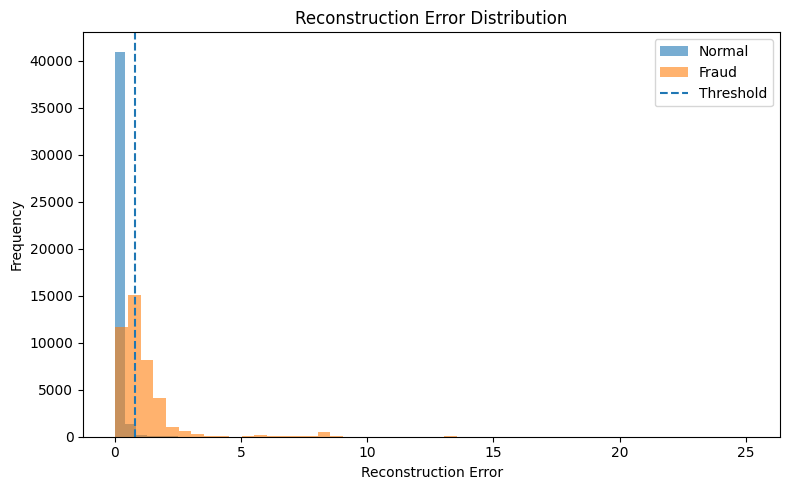

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(reconstruction_error_test[y_test == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(reconstruction_error_test[y_test == 1], bins=50, alpha=0.6, label="Fraud")
plt.axvline(threshold, linestyle="--", label="Threshold")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "autoencoder_reconstruction_error_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
percentiles = [95, 97, 98, 99, 99.2, 99.5, 99.7, 99.8, 99.9]

results = []

for p in percentiles:
    threshold_candidate = np.percentile(reconstruction_error_val[y_val == 0], p)
    y_pred_temp = (reconstruction_error_test > threshold_candidate).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()

    results.append({
        "percentile": p,
        "threshold": threshold_candidate,
        "accuracy": accuracy_score(y_test, y_pred_temp),
        "precision_fraud": precision_score(y_test, y_pred_temp, zero_division=0),
        "recall_fraud": recall_score(y_test, y_pred_temp, zero_division=0),
        "f1_fraud": f1_score(y_test, y_pred_temp, zero_division=0),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    })

threshold_results = pd.DataFrame(results)
threshold_results.to_csv(RESULTS_DIR / "autoencoder_threshold_results.csv", index=False)
threshold_results

,percentile,threshold,accuracy,precision_fraud,recall_fraud,f1_fraud,true_negatives,false_positives,false_negatives,true_positives
0,95.0,0.384930,0.893229,0.943627,0.836425,0.886798,40517,2131,6976,35671
1,97.0,0.482687,0.863861,0.962092,0.757568,0.847668,41375,1273,10339,32308
2,98.0,0.580257,0.831936,0.970862,0.684409,0.802850,41772,876,13459,29188
3,99.0,0.815489,0.742459,0.980528,0.494736,0.657648,42229,419,21548,21099
4,99.2,0.909616,0.712328,0.982213,0.432481,0.600537,42314,334,24203,18444
5,99.5,1.199076,0.649663,0.984956,0.303960,0.464557,42450,198,29684,12963
6,99.7,1.642777,0.571815,0.983578,0.146060,0.254349,42544,104,36418,6229
7,99.8,2.051059,0.540079,0.980596,0.081764,0.150943,42579,69,39160,3487
8,99.9,2.920589,0.524028,0.987161,0.048679,0.092782,42621,27,40571,2076


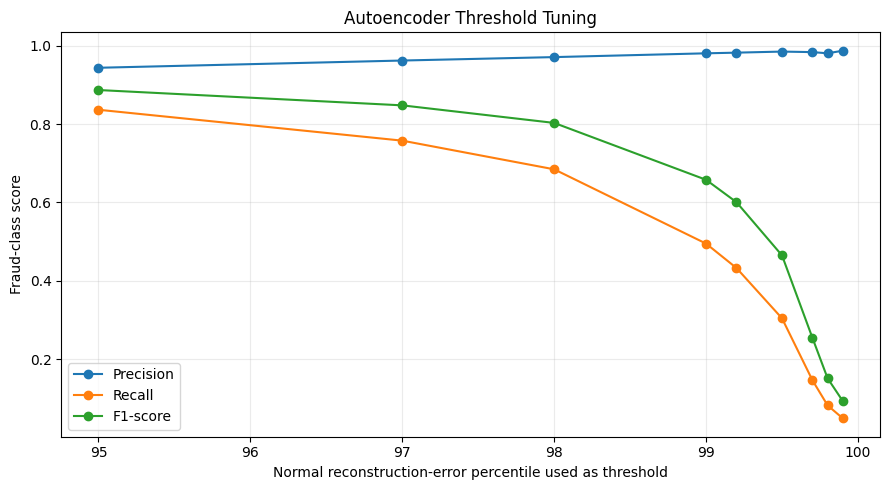

In [21]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_results["percentile"], threshold_results["precision_fraud"], marker="o", label="Precision")
plt.plot(threshold_results["percentile"], threshold_results["recall_fraud"], marker="o", label="Recall")
plt.plot(threshold_results["percentile"], threshold_results["f1_fraud"], marker="o", label="F1-score")
plt.xlabel("Normal reconstruction-error percentile used as threshold")
plt.ylabel("Fraud-class score")
plt.title("Autoencoder Threshold Tuning")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "autoencoder_threshold_tuning.png", dpi=300, bbox_inches="tight")
plt.show()

### Comparação final dos modelos

In [22]:
best_autoencoder = threshold_results.sort_values(
    ["f1_fraud", "recall_fraud"],
    ascending=False
).iloc[0]

supervised_metrics = pd.read_csv(RESULTS_DIR / "logistic_regression_metrics.csv")
unsupervised_metrics = pd.DataFrame({
    "Model": ["Autoencoder (best F1 threshold)"],
    "Accuracy": [best_autoencoder["accuracy"]],
    "Precision": [best_autoencoder["precision_fraud"]],
    "Recall": [best_autoencoder["recall_fraud"]],
    "F1-score": [best_autoencoder["f1_fraud"]],
    "ROC-AUC": [roc_auc],
    "PR-AUC": [pr_auc],
    "Best Threshold Percentile": [best_autoencoder["percentile"]],
    "Threshold": [best_autoencoder["threshold"]],
})

for col in ["Best Threshold Percentile", "Threshold"]:
    if col not in supervised_metrics.columns:
        supervised_metrics[col] = np.nan

model_comparison = pd.concat(
    [supervised_metrics, unsupervised_metrics],
    ignore_index=True,
    sort=False,
)
model_comparison.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Best Threshold Percentile,Threshold
0,Logistic Regression,0.964887,0.976658,0.952588,0.964473,0.993334,0.994533,NaN,NaN
1,Autoencoder (best F1 threshold),0.893229,0.943627,0.836425,0.886798,0.945786,0.949521,95.0,0.38493


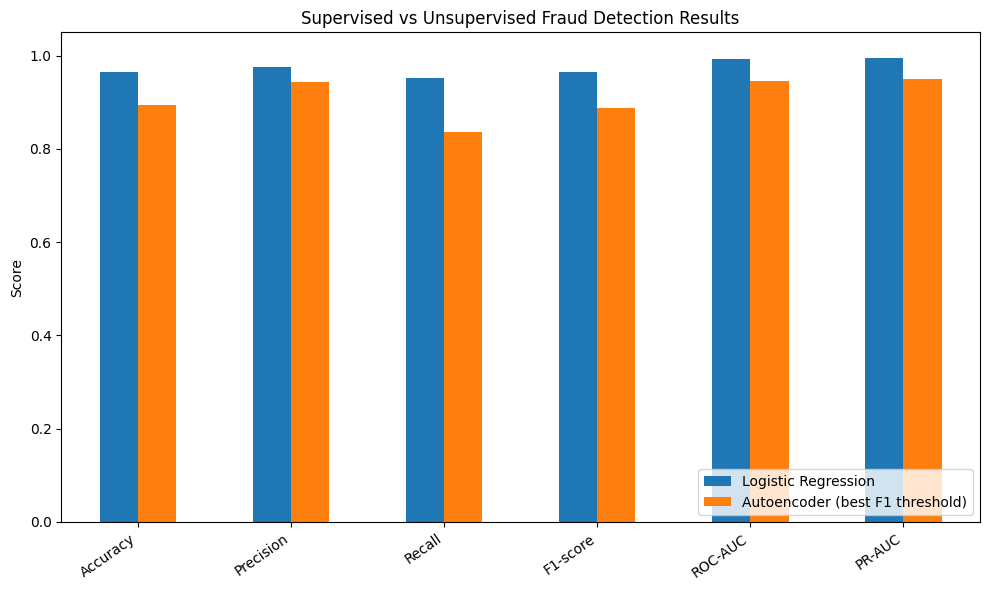

In [23]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
plot_df = model_comparison.set_index("Model")[metrics_to_plot]

ax = plot_df.T.plot(kind="bar", figsize=(10, 6))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Supervised vs Unsupervised Fraud Detection Results")
plt.xticks(rotation=35, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "model_comparison_metrics.png", dpi=300, bbox_inches="tight")
plt.show()